# Setup

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parents[1]
sys.path.append(str(PROJECT_ROOT))

print("Added to PYTHONPATH:", PROJECT_ROOT)

Added to PYTHONPATH: c:\Users\yfess\Desktop\timeseries-thesis


In [2]:
from dotenv import load_dotenv
import os

env_file = PROJECT_ROOT / ".env"
print(env_file.exists())
load_dotenv(env_file)
print("Loaded env file:", env_file)

True
Loaded env file: c:\Users\yfess\Desktop\timeseries-thesis\.env


In [3]:
from src.common.config import load_config
from src.common.logger import get_logger
from src.databases.benchmark_db.config import get_postgres_config
from src.databases.benchmark_db.benchmark_db import BenchmarkDB

benchmarkdb_config_file_path = PROJECT_ROOT / "configs/config-benchmarkdb.yml"
benchmarkdb_config_dict = load_config(benchmarkdb_config_file_path)

logger = get_logger("benchmark_db", benchmarkdb_config_dict["general"]["log_file"])
benchmarkdb_config = get_postgres_config(benchmarkdb_config_dict["database"])
benchmarkdb_repo = BenchmarkDB(benchmarkdb_config, logger)

try:
    benchmarkdb_repo.connect()
    print("Connected to BenchmarkDB successfully.")
except Exception as e:
    print("Failed to connect to BenchmarkDB:", e)

Connected to BenchmarkDB successfully.


# Load Results

In [4]:
read_cardinality_ALL = benchmarkdb_repo.get_all_read_cardinality_benchmark_results()
len(read_cardinality_ALL)

27

In [5]:
one_r = read_cardinality_ALL[0]
print(one_r.to_dict())

{'id': 1, 'benchmark_name': 'read.cardinality', 'database_system': 'influxdb', 'database_version': '2.7', 'cardinality_level': 'single_sensor', 'parameter': 'sea_water_temperature', 'node_source_id': 'sfi_smart_ocean;demo;d1;1', 'range_window': '1_month', 'start_time': '2020-01-01T00:00:00+00:00', 'end_time': '2020-01-31T00:00:00+00:00', 'result_row_count': 0, 'elapsed_time_seconds': 0.009408768, 'elapsed_time_ns': 9408768, 'created_at': '2026-08-15T11:40:17.712231+00:00'}


# Partition & Colors

In [6]:
from collections import defaultdict

db_results = defaultdict(list)
for r in read_cardinality_ALL:
    db_results[r.database_system].append(r)

db_systems = sorted(db_results.keys())
db_systems

['influxdb', 'mongodb', 'timescaledb']

In [7]:
DB_COLOR_MAP = {
    'mongodb':     '#00ED64',
    'influxdb':    '#F18F13',
    'timescaledb': '#0064FF',
    'questdb':     '#FF5733',
}
DB_COLORS = ['#00ED64', '#F18F13', '#0064FF', '#FF5733', '#A855F7', '#EC4899']

db_color = {
    db: DB_COLOR_MAP.get(db, DB_COLORS[i % len(DB_COLORS)])
    for i, db in enumerate(db_systems)
}
db_color

{'influxdb': '#F18F13', 'mongodb': '#00ED64', 'timescaledb': '#0064FF'}

# DataFrame

In [8]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

rows = []
for db in db_systems:
    for r in db_results[db]:
        rows.append({
            'database_system': db,
            'cardinality_level': r.cardinality_level,
            'result_row_count': r.result_row_count,
            'elapsed_ns': r.elapsed_time_ns,
            'elapsed_ms': r.elapsed_time_ns / 1_000_000,
        })

df = pd.DataFrame(rows)
df.head()

,database_system,cardinality_level,result_row_count,elapsed_ns,elapsed_ms
0,influxdb,single_sensor,0,9408768,9.408768
1,influxdb,single_sensor,0,13159737,13.159737
2,influxdb,single_sensor,0,9413649,9.413649
3,influxdb,single_parameter_all_nodes,0,9308829,9.308829
4,influxdb,single_parameter_all_nodes,0,9134448,9.134448


# Order Levels Logically

In [9]:
LEVEL_ORDER = ["single_sensor", "single_parameter_all_nodes", "all"]

df['cardinality_level'] = pd.Categorical(df['cardinality_level'], categories=LEVEL_ORDER, ordered=True)
levels_present = [l for l in LEVEL_ORDER if l in df['cardinality_level'].unique()]
levels_present

['single_sensor', 'single_parameter_all_nodes', 'all']

# Raw Data Points + Mean Line, per Database

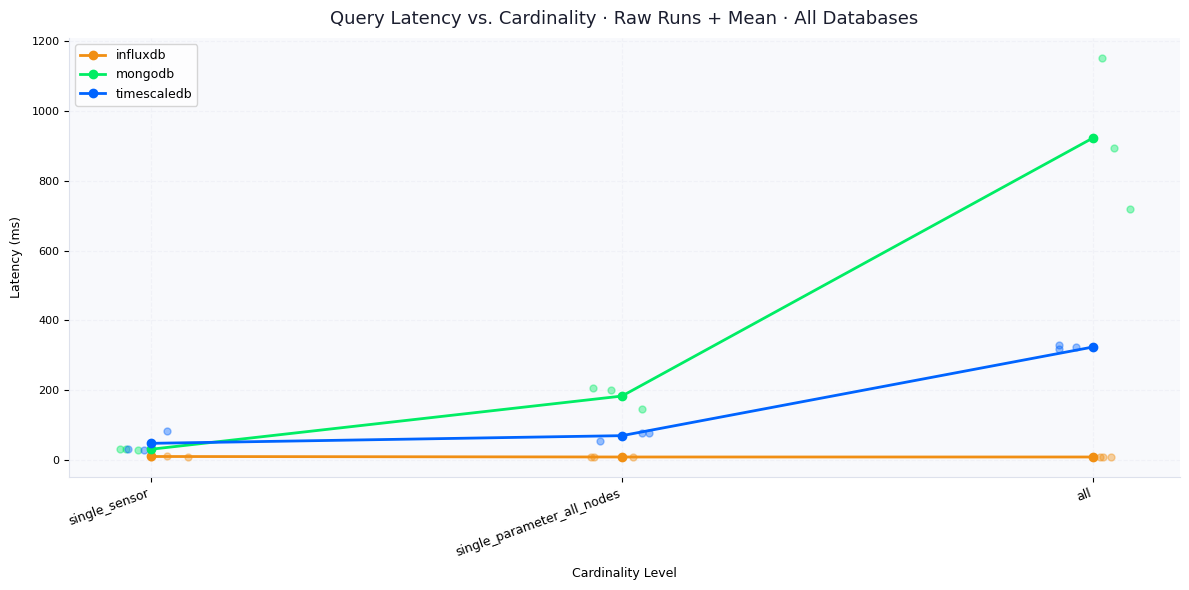

In [10]:
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#ffffff')
ax.set_facecolor('#f8f9fc')

x_positions = {l: i for i, l in enumerate(levels_present)}

for db in db_systems:
    sub = df[df['database_system'] == db]

    for l in levels_present:
        vals = sub[sub['cardinality_level'] == l]['elapsed_ms'].values
        if len(vals) == 0:
            continue
        jitter = np.random.uniform(-0.08, 0.08, size=len(vals))
        xs = np.full(len(vals), x_positions[l]) + jitter
        ax.scatter(xs, vals, color=db_color[db], alpha=0.4, s=25, zorder=2)

    means = [
        sub[sub['cardinality_level'] == l]['elapsed_ms'].mean() if l in sub['cardinality_level'].values else np.nan
        for l in levels_present
    ]
    ax.plot(range(len(levels_present)), means, marker='o', color=db_color[db], linewidth=2, label=db, zorder=3)

ax.set_xticks(range(len(levels_present)))
ax.set_xticklabels(levels_present, rotation=20, ha='right', fontsize=9)
ax.set_xlabel('Cardinality Level', fontsize=9, labelpad=6)
ax.set_ylabel('Latency (ms)', fontsize=9, labelpad=6)
ax.set_title('Query Latency vs. Cardinality · Raw Runs + Mean · All Databases', fontsize=13, pad=10, color='#1a1d2e')
ax.tick_params(axis='y', labelsize=8)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#dde1ec')
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.4, color='#e4e7f0', linestyle='--', zorder=0)

plt.tight_layout()
plt.show()

# Same Chart, Log Scale

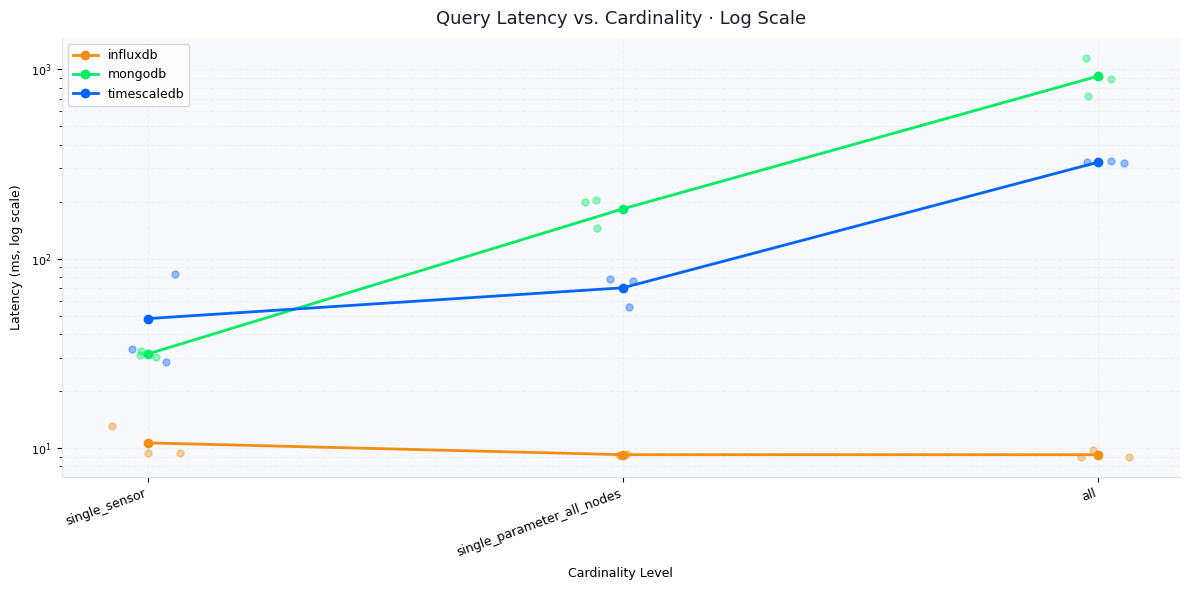

In [11]:
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#ffffff')
ax.set_facecolor('#f8f9fc')

for db in db_systems:
    sub = df[df['database_system'] == db]

    for l in levels_present:
        vals = sub[sub['cardinality_level'] == l]['elapsed_ms'].values
        if len(vals) == 0:
            continue
        jitter = np.random.uniform(-0.08, 0.08, size=len(vals))
        xs = np.full(len(vals), x_positions[l]) + jitter
        ax.scatter(xs, vals, color=db_color[db], alpha=0.4, s=25, zorder=2)

    means = [
        sub[sub['cardinality_level'] == l]['elapsed_ms'].mean() if l in sub['cardinality_level'].values else np.nan
        for l in levels_present
    ]
    ax.plot(range(len(levels_present)), means, marker='o', color=db_color[db], linewidth=2, label=db, zorder=3)

ax.set_yscale('log')
ax.set_xticks(range(len(levels_present)))
ax.set_xticklabels(levels_present, rotation=20, ha='right', fontsize=9)
ax.set_xlabel('Cardinality Level', fontsize=9, labelpad=6)
ax.set_ylabel('Latency (ms, log scale)', fontsize=9, labelpad=6)
ax.set_title('Query Latency vs. Cardinality · Log Scale', fontsize=13, pad=10, color='#1a1d2e')
ax.tick_params(axis='y', labelsize=8)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#dde1ec')
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, which='both', alpha=0.4, color='#e4e7f0', linestyle='--', zorder=0)

plt.tight_layout()
plt.show()

# Relative Slowdown — Mongo's $unwind Hypothesis

In [12]:
pivot_df = df.pivot_table(
    index='cardinality_level',
    columns='database_system',
    values='elapsed_ms',
    aggfunc='mean',
).reindex(levels_present)

pivot_df = pivot_df[db_systems]

# normalize each column so single_sensor = 1.0, showing relative growth
normalized_df = pivot_df / pivot_df.iloc[0]
normalized_df.round(2)

database_system,influxdb,mongodb,timescaledb
cardinality_level,,,
single_sensor,1.00,1.00,1.00
single_parameter_all_nodes,0.87,5.85,1.45
all,0.87,29.39,6.71


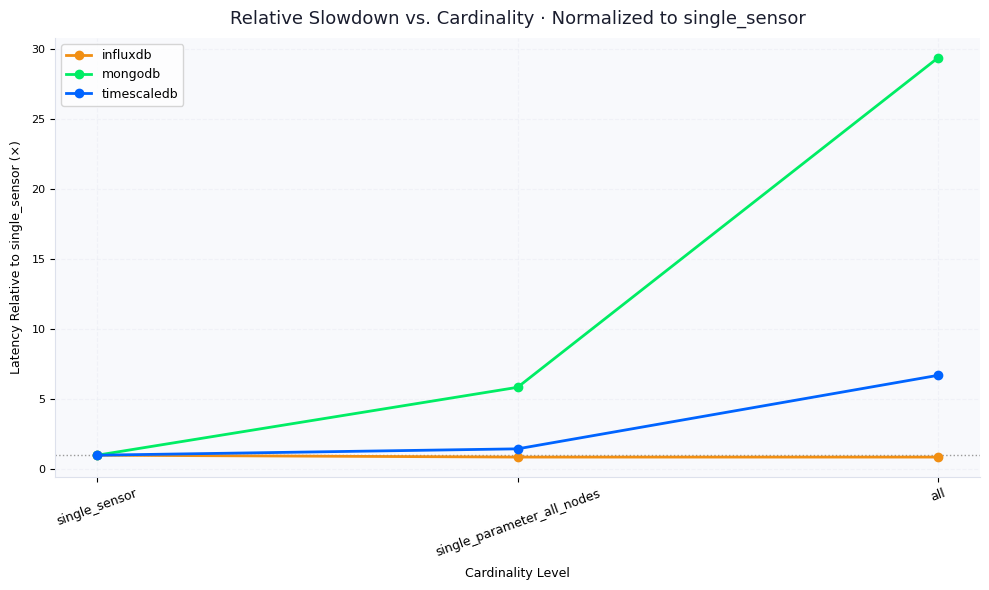

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#ffffff')
ax.set_facecolor('#f8f9fc')

for db in db_systems:
    ax.plot(levels_present, normalized_df[db], marker='o', color=db_color[db], linewidth=2, label=db, zorder=3)

ax.axhline(1.0, color='#999999', linestyle=':', linewidth=1, zorder=1)
ax.set_xlabel('Cardinality Level', fontsize=9, labelpad=6)
ax.set_ylabel('Latency Relative to single_sensor (×)', fontsize=9, labelpad=6)
ax.set_title('Relative Slowdown vs. Cardinality · Normalized to single_sensor', fontsize=13, pad=10, color='#1a1d2e')
ax.tick_params(axis='x', rotation=20, labelsize=9)
ax.tick_params(axis='y', labelsize=8)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#dde1ec')
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.4, color='#e4e7f0', linestyle='--', zorder=0)

plt.tight_layout()
plt.show()

# Summary Table

In [14]:
summary_df = pivot_df.round(3)
summary_df

database_system,influxdb,mongodb,timescaledb
cardinality_level,,,
single_sensor,10.661,31.377,48.311
single_parameter_all_nodes,9.231,183.591,70.268
all,9.227,922.056,323.937


# Row Count Sanity Check

In [15]:
row_count_pivot = df.pivot_table(
    index='cardinality_level',
    columns='database_system',
    values='result_row_count',
    aggfunc='mean',
).reindex(levels_present)

row_count_pivot = row_count_pivot[db_systems]
row_count_pivot

database_system,influxdb,mongodb,timescaledb
cardinality_level,,,
single_sensor,0.0,1441.0,1441.0
single_parameter_all_nodes,0.0,7205.0,7205.0
all,0.0,36025.0,36025.0
